# CVRIE - Supervised Learning: Pneumonia Classification

This notebook contains CVRIE's supervised-learning part: a classifier that analyzes chest X-ray images and predicts whether a patient has pneumonia.

**Dataset:** RSNA Pneumonia processed version, from `iamtapendu/rsna-pneumonia-processed-dataset` on Kaggle.

**Dataset choice justification:** the dataset matches each patient into either pneumonia or healthy, 0 or 1, which matches the requirements and is pretty easy to work with, also it's pretty large (something close to 3GB) which is prevents me from having to work with a limited dataset.

**Toolset constraint:** only Scikit-learn, Pandas and NumPy arrays are used for the computations. This rules out CNNs (which would require a CNN library such as TensorFlow, PyTorch or Brainz), instead, so I had to use a more basic pipeline: flattened grayscale pixels -> standardization -> dimensionality reduction -> a classifier (Logistic Regression / Random Forest).

In [108]:
import constants
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import DatasetLoader
from   PIL                     import Image
from   sklearn.model_selection import train_test_split, cross_val_score
from   sklearn.preprocessing   import StandardScaler
from   sklearn.decomposition   import PCA
from   sklearn.linear_model    import LogisticRegression
from   sklearn.ensemble        import RandomForestClassifier
from   sklearn.dummy           import DummyClassifier
from   sklearn.metrics         import classification_report, ConfusionMatrixDisplay

#  V The dataset only contains images and their associated labels. You may trim additional information.
#  V The overall dataset is representative of a classification issue.
#  ? You are able to justify your choice.( Choosing the same dataset as another group without justification is forbidden.)

#  V Your data could need to be normalised. Images of different sizes, color palettes or resolution might need  some pre-processing.
#  V Your data could be unbalanced. Are positive and negative cases both present and equally represented in your data?
#  V (X) Are there outliers that skew the data in specific directions or extremes?

# (V) How do you split training data from evaluation data?

## 1. Analizing the Data

Load the metadata, confirm every image/mask file referenced actually exists.
And show the contents of the first columns before the preprocessing.

In [109]:
train_metadata = pd.read_csv(constants.PENUMONIA_TRAIN_CSV)

for patient_id in train_metadata.get("patientId"):
    for folder in (constants.PNEUMONIA_TRAIN_IMAGES, constants.PNEUMONIA_TRAIN_MASKS):
        filepath = f"{folder}/{patient_id}.png"
        try:
            with open(filepath):
                pass
        except FileNotFoundError:
            print(f"File '{filepath}' not found.")
            raise

print("Training data files present.")
train_metadata.head()

Training data files present.


,patientId,x,y,width,height,Target,class,age,sex,modality,position
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,51,F,CR,PA
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,48,F,CR,PA
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,19,M,CR,AP
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0,Normal,28,M,CR,PA
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1,Lung Opacity,32,F,CR,AP


In [110]:
for key in train_metadata.columns:
    print()
    print(train_metadata[key].value_counts())

print("\nNaNs:")
NaNs = train_metadata.isnull().sum()
print(NaNs[NaNs > 0])


patientId
0ab261f9-4eb5-42ab-a9a5-e918904d6356    4
0d5bc737-03de-4bb8-98a1-45b7180c3e0f    4
1bf08f3b-a273-4f51-bafa-b55ada2c23b5    4
31764d54-ea3b-434f-bae2-8c579ed13799    4
3239951b-6211-4290-b237-3d9ad17176db    4
                                       ..
c1cf3255-d734-4980-bfe0-967902ad7ed9    1
c1e228e4-b7b4-432b-a735-36c48fdb806f    1
c1e3eb82-c55a-471f-a57f-fe1a823469da    1
c1edf42b-5958-47ff-a1e7-4f23d99583ba    1
c1f6b555-2eb1-4231-98f6-50a963976431    1
Name: count, Length: 26684, dtype: int64

x
599.0    46
583.0    44
193.0    43
615.0    43
225.0    41
         ..
776.0     1
767.0     1
799.0     1
764.0     1
753.0     1
Name: count, Length: 748, dtype: int64

y
257.0    38
436.0    36
420.0    36
498.0    35
445.0    33
         ..
785.0     1
716.0     1
792.0     1
684.0     1
774.0     1
Name: count, Length: 726, dtype: int64

width
219.0    83
217.0    82
222.0    80
214.0    75
240.0    74
         ..
376.0     1
56.0      1
78.0      1
67.0      1
65.0      1

### Class balance

The `Target` column is the label we are trying to predict (0 = no pneumonia, 1 = pneumonia). Plotting it directly shows whether the dataset is balanced - if it isn't, that changes which metrics matter (accuracy alone becomes misleading) and motivates using `class_weight="balanced"` later.

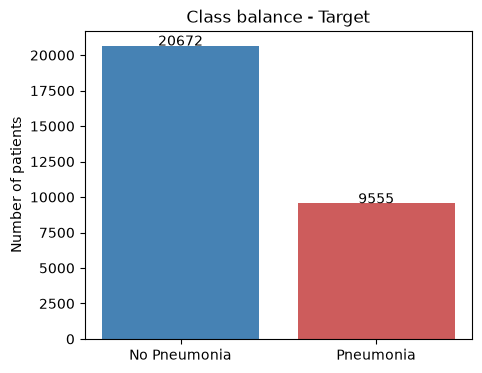

Target
0    20672
1     9555
Name: count, dtype: int64
Positive class ratio: 0.3161081152611903


In [111]:
target_counts = train_metadata["Target"].value_counts().sort_index()

plt.figure(figsize = (5, 4))
plt.bar(["No Pneumonia", "Pneumonia"], target_counts.values, color = ["steelblue", "indianred"])
plt.ylabel("Number of patients")
plt.title("Class balance - Target")
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 5, str(v), ha = "center")
plt.show()

print(target_counts)
print("Positive class ratio:", target_counts[1] / target_counts.sum())

### Sample images per class

The pneumonia itself is pretty visible to the untrained eye as the lungs look "fuller/denser" on the radiography, from comments on similar datasets I think it comes from mucus and inflamations or something but I haven't looked too deeply into it, here is what they look like:

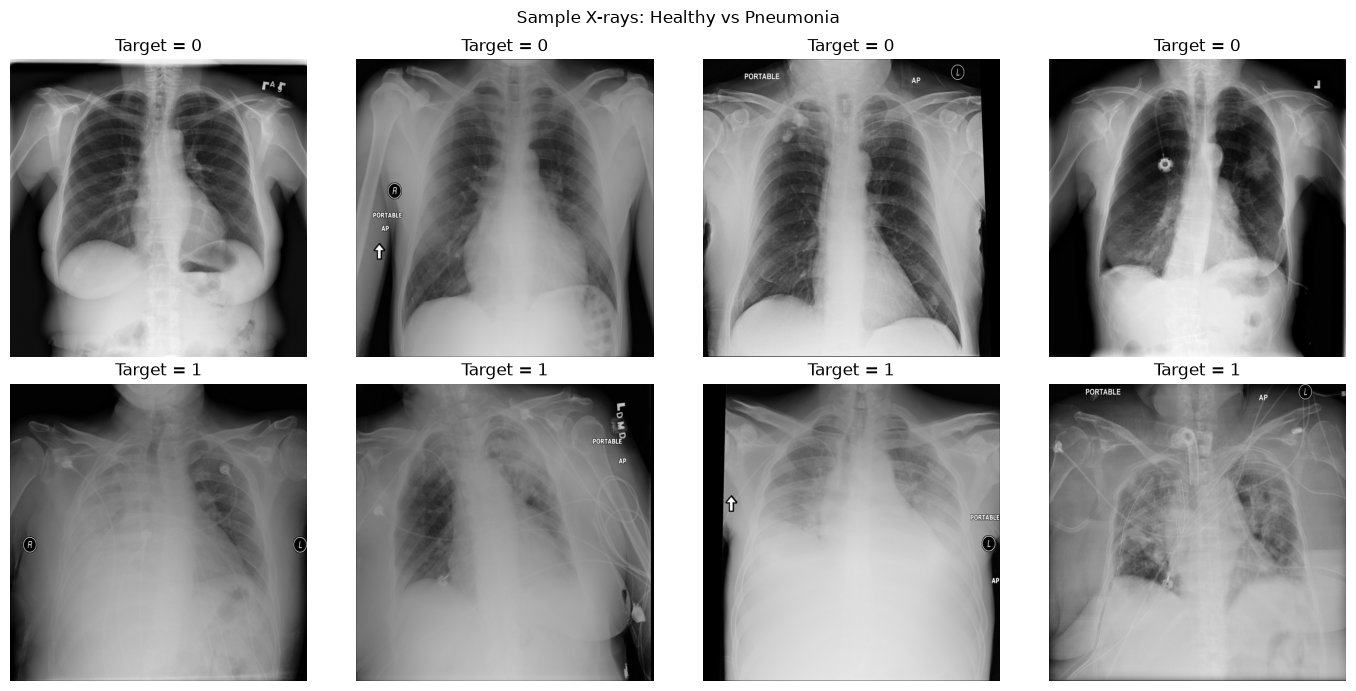

In [112]:
fig, axes = plt.subplots(2, 4, figsize = (14, 7))

for label, row in zip([0, 1], axes):
    sample_indices = train_metadata[train_metadata["Target"] == label]["patientId"].sample(4, random_state = 0)
    for ax, pid in zip(row, sample_indices):
        img = Image.open(f"{constants.PNEUMONIA_TRAIN_IMAGES}/{pid}.png").convert("L")
        ax.imshow(img, cmap = "gray")
        ax.set_title(f"Target = {label}")
        ax.axis("off")

plt.suptitle("Sample X-rays: Healthy vs Pneumonia")
plt.tight_layout()
plt.show()

### Showing what the masks look like:

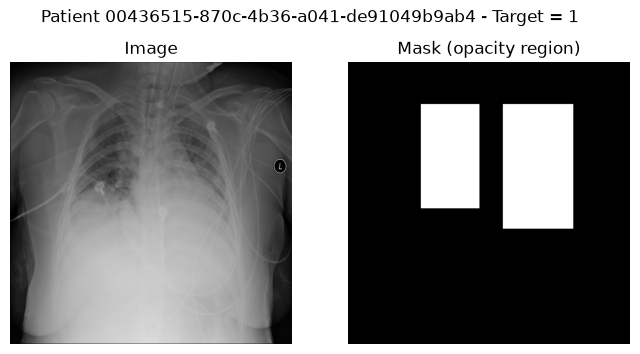

In [113]:
positive_id = train_metadata[train_metadata["Target"] == 1]["patientId"].iloc[0]

img  = Image.open(f"{constants.PNEUMONIA_TRAIN_IMAGES}/{positive_id}.png").convert("L")
mask = Image.open(f"{constants.PNEUMONIA_TRAIN_MASKS}/{positive_id}.png").convert("L")

fig, axes = plt.subplots(1, 2, figsize = (8, 4))
axes[0].imshow(img,  cmap = "gray")
axes[0].set_title("Image"); axes[0].axis("off")
axes[1].imshow(mask, cmap = "gray")
axes[1].set_title("Mask (opacity region)")
axes[1].axis("off")
plt.suptitle(f"Patient {positive_id} - Target = 1")
plt.show()

### Trimming additional information (as required by the PDF)

Columns like `class`, `age`, `sex`, `Modality` are **not** used as model inputs:
They stay in the dataframe for debuging and to analize the dataset but don't go into `dataset_x`.

## 2. Preprocessing

Steps applied to every image, in order:
1. **Grayscale conversion** (`convert("L")`) X-rays are grayscale so 3 RGB channels is redundant.
2. **Resize** to a fixed resolution because Scikit-learn needs vectors of the same lenght.
3. **Flatten** the images turns each 2D image into a 1D pixel vector.
4. **Standardize** (`StandardScaler`) - centers every pixel-position feature to mean 0 / std 1, for pixels values to be relative and not absolute (kind of).
5. **PCA** - reduces the dimentionality of the pixel vector, keeping the directions of maximum variance and discarding largely redundant/noisy ones. This reduces the possiblity of overfitting and prevents my laptop from blowing up by have to do computations involving 160000-dimentional vectors instead of like 1600-dimentional vectors.

Loss function used: Logistic Regression minimizes **log-loss** (cross-entropy), which penalizes confident-but-wrong predictions heavily and is the standard loss for binary classification from probabilistic output.

In [121]:
def load_training_data(
        train_metadata:    pd.DataFrame,
        load_len:          int,
        img_size:          tuple[int, int],
        reduced_dimention: int
) -> np.array:

    dataset_x = []
    assert (load_len >= reduced_dimention or load_len == -1)

    print("Loading dataset from source...")

    for i, patient in train_metadata.iterrows():

        if (i >= load_len and load_len != -1):
            break

        dataset_x.append(
            np.array(
                Image.open(f"{constants.PNEUMONIA_TRAIN_IMAGES}/{patient.patientId}.png").convert("L").resize(img_size)
            ).flatten()
        )

    print("Done.\n")

    print("Standardizing dataset...")
    dataset_x = StandardScaler().fit_transform(dataset_x)
    print("Done.\n")

    print("Reducing dataset dimensionality...")
    pca = PCA(n_components = constants.REDUCED_DIMENTION)
    dataset_x = pca.fit_transform(dataset_x)
    print("Done.\n")

    return np.array(dataset_x)

dataset_x, dataset_y = DatasetLoader.load_or_build_cache(load_training_data)
print(dataset_x.shape, dataset_y.shape)

Loading dataset from cache...
Done.

Dataset successfully loaded.
(4000, 400) (4000,)


## 3. Train / Test Split

Stratified 80/20 split - `stratify = dataset_y` keeps the same pneumonia/normal ratio in both the training and test sets, matching the class balance checked above.

In [115]:
train_x, test_x, train_y, test_y = train_test_split(
    dataset_x,
    dataset_y,
    train_size = 0.8,
    stratify   = dataset_y
)

print("Train:", train_x.shape, "Test:", test_x.shape)

Train: (3200, 400) Test: (800, 400)


## 4. Model Training & Comparison

- **Dummy baseline** (`most_frequent`) always predicts the majority class. The best possible negative-IQ model.
- **Logistic Regression** - a linear classifier; fast, minimizes log-loss via gradient-based optimization. Used as the primary baseline since it fits the binary-classification shape directly and pairs well with PCA's linear components (as it expects features).
- **Random Forest** - a nonlinear ensemble of decision trees; since it's non-linear it can capture patterns Logistic Regression's linear boundary cannot, I believe it's way more prone to overfitting than Logistic Regression though (this issue kinda goes away as `max_depth` decreases).

`class_weight = "balanced"` is used on both models to counter the class imbalance measured it reweights the loss so misclassifying the minority target (pneumonia) class is penalized more heavily.

Each model is evaluated with 5-fold cross-validation (`cv = 5`) on F1 score rather than a single train/test split, since F1 accounts for the dataset imbalance (if the dataset is 80% pneumonia a 0.8 accuracy is equivalent to a 0.5 accuracy on a dataset that's 50% pneumonia, F1 accounts for that so it's more usefull that accuracy), cross-validation gives a more reliable estimate than one lucky/unlucky split because it runs the score multiple times and averages the results.

In [116]:
def test_model(model_class, *args, **kwargs) -> tuple[float, float, object]:

    model = model_class(*args, **kwargs)
    model.fit(train_x, train_y)

    scores = cross_val_score(
        model,
        dataset_x, dataset_y.ravel(),
        cv = 5, scoring = "f1"
    )

    return (scores.mean(), scores.std(), model)

results = {}

results["Dummy (most_frequent)"] = test_model(DummyClassifier, strategy = "most_frequent")
# balanced accounts for the 1/2 pneumonia/healthy ratio
results["Logistic Regression"]   = test_model(LogisticRegression, max_iter = 5000, class_weight="balanced")
results["Random Forest"]         = test_model(RandomForestClassifier, n_estimators = 300, max_depth = 6, class_weight = "balanced")

for name, (mean, std, _) in results.items():
    print(f"{name:25s}  F1 mean={mean:.4f}  F1 std={std:.4f}")

Dummy (most_frequent)      F1 mean=0.0000  F1 std=0.0000
Logistic Regression        F1 mean=0.7135  F1 std=0.0256
Random Forest              F1 mean=0.7203  F1 std=0.0119


### Random Forest depth

`n_estimators` doesn't really move test performance once the model is insanely overfit because the train score gets stuck at 1.0.
`max_depth` does impact overfitting a lot though as I said earlier, check this out:

max_depth=2  F1 mean=0.7202
max_depth=4  F1 mean=0.7326
max_depth=6  F1 mean=0.7160
max_depth=8  F1 mean=0.6952
max_depth=10  F1 mean=0.6664
max_depth=None  F1 mean=0.5452


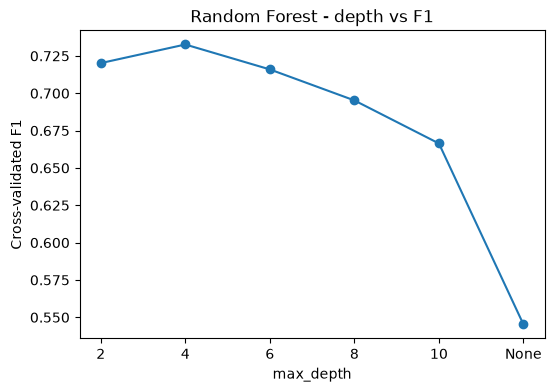

In [117]:
depths = [2, 4, 6, 8, 10, None]
depth_scores = []

for depth in depths:
    mean, std, _ = test_model(RandomForestClassifier, n_estimators = 300, max_depth = depth, class_weight = "balanced")
    depth_scores.append(mean)
    print(f"max_depth={depth}  F1 mean={mean:.4f}")

plt.figure(figsize = (6, 4))
plt.plot([str(d) for d in depths], depth_scores, marker = "o")
plt.xlabel("max_depth")
plt.ylabel("Cross-validated F1")
plt.title("Random Forest - depth vs F1")
plt.show()

### Comparison table (just a clearer version of the ouput from earlier)

In [118]:
comparison_df = pd.DataFrame([
    {"model": name, "f1_mean": mean, "f1_std": std}
    for name, (mean, std, _) in results.items()
]).sort_values("f1_mean", ascending=False)

comparison_df

,model,f1_mean,f1_std
2,Random Forest,0.720326,0.011931
1,Logistic Regression,0.713508,0.025565
0,Dummy (most_frequent),0.000000,0.000000


## 5. Precision/Recall

More useful the cross-validated F1 above, look at the full report (precision/recall/F1 per class) and confusion matrix for the best-performing model you can see whether the model is missing real pneumonia cases (low recall on class 1), which matters the most as missed pneumonia will lead to deaths.

In [119]:
# this is because I deem (mean - std) the best metric for a model
comparison_df["score"] = comparison_df["f1_mean"] - comparison_df["f1_std"]
comparison_df = comparison_df.sort_values("score", ascending = False)

best_name = comparison_df.iloc[0]["model"]
best_model = results[best_name][2]

pred_y = best_model.predict(test_x)

print(f"Best model: {best_name}\n")
print("Train accuracy:", best_model.score(train_x, train_y))
print("Test accuracy: ", best_model.score(test_x, test_y))
print()
print(classification_report(test_y, pred_y, target_names = ["No Pneumonia", "Pneumonia"]))

Best model: Random Forest

Train accuracy: 0.928125
Test accuracy:  0.82875

              precision    recall  f1-score   support

No Pneumonia       0.85      0.82      0.83       416
   Pneumonia       0.81      0.84      0.83       384

    accuracy                           0.83       800
   macro avg       0.83      0.83      0.83       800
weighted avg       0.83      0.83      0.83       800



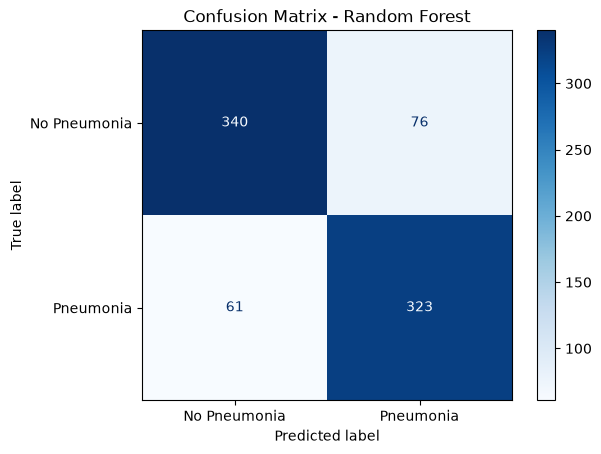

In [120]:
ConfusionMatrixDisplay.from_predictions(
    test_y, pred_y,
    display_labels = ["No Pneumonia", "Pneumonia"],
    cmap = "Blues"
)
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

## 6. Conclusion

- The chosen model clearly outperforms the dummy baseline, which means that the pipeline actually recognizes pneumonia to some extent.
- **Limitation - no CNN.** This pipeline uses dimensionality reduction (PCA) and classifiers rather than a CNN, since the allowed libraries (Scikit-learn, Pandas, NumPy, Matplotlib) aren't deep-learning libraries. PCA finds directions of maximum variance *even if they don't help distinguish pneumonia from normal because it doesn't know about the labels*, unlike with a CNN.
- **Sample size vs. feature count.** PCA's component count is capped by the number of training samples, this was *a real pain for my laptop* during dataset sizing.
- **Computation durations:** I waited close to an hour waiting for my automated hyperparameter fine-tuning loops to conclude only to come back to a printing error in VSCode because of a misspelled variable name. Many such cases.